In [1]:
import os
import pandas as pd
import geopandas as gpd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
y = 'rich_har'

In [9]:
data = gpd.read_file('features_forEDA.geojson')
data.head()

,id,Autumn_EVI_median,Autumn_EVI_stdDev,Autumn_MSAVI_median,Autumn_MSAVI_stdDev,Autumn_NDMI_median,Autumn_NDMI_stdDev,Autumn_NDVI_median,Autumn_NDVI_stdDev,Autumn_SWIR_ratio_median,...,swir2_p50,swir2_p75,swir2_p90,swir2_stdDev,tpi,urban_prox10m,urban_prox360m,urban_prox500m,urban_prox90m,geometry
0,1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_...,198,406,86,33,-75,31,75,31,51,...,128940,208325,455200,140792,-140,0,0,165,0,POINT (17.73773 49.37756)
1,1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_...,172,151,79,32,-66,29,66,29,54,...,134300,229333,458900,143224,-180,0,5,157,0,POINT (17.7362 49.37747)
2,1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_...,224,1332,88,22,-78,24,78,24,48,...,126685,199825,390700,128556,121,0,0,0,0,POINT (17.61592 48.88537)
3,1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_...,246,581,90,25,-83,26,83,26,46,...,92700,183800,406700,156029,-40,0,0,0,0,POINT (17.68832 48.89229)
4,1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_...,223,275,90,24,-82,25,82,25,46,...,111300,196166,413850,157151,77,0,0,0,0,POINT (17.68877 48.89292)


In [10]:
list(data.columns)

['id',
 'Autumn_EVI_median',
 'Autumn_EVI_stdDev',
 'Autumn_MSAVI_median',
 'Autumn_MSAVI_stdDev',
 'Autumn_NDMI_median',
 'Autumn_NDMI_stdDev',
 'Autumn_NDVI_median',
 'Autumn_NDVI_stdDev',
 'Autumn_SWIR_ratio_median',
 'Autumn_SWIR_ratio_stdDev',
 'Carpathians_2018_Mowing_Intensity_DOY1',
 'Carpathians_2018_Mowing_Intensity_n_mowing',
 'Carpathians_2019_Mowing_Intensity_DOY1',
 'Carpathians_2019_Mowing_Intensity_n_mowing',
 'Carpathians_2020_Mowing_Intensity_DOY1',
 'Carpathians_2020_Mowing_Intensity_n_mowing',
 'Carpathians_2021_Mowing_Intensity_DOY1',
 'Carpathians_2021_Mowing_Intensity_n_mowing',
 'Carpathians_2022_Mowing_Intensity_DOY1',
 'Carpathians_2022_Mowing_Intensity_n_mowing',
 'Carpathians_2023_Mowing_Intensity_DOY1',
 'Carpathians_2023_Mowing_Intensity_n_mowing',
 'Carpathians_2024_Mowing_Intensity_DOY1',
 'Carpathians_2024_Mowing_Intensity_n_mowing',
 'DOY1',
 'EVI_median',
 'EVI_p10',
 'EVI_p25',
 'EVI_p50',
 'EVI_p75',
 'EVI_p90',
 'EVI_stdDev',
 'MSAVI_median',
 'MSA

In [11]:
# Základné informácie o dátach
print("Rozmery dát:", data.shape)
print("\nDáta typy:")
print(data.dtypes.value_counts())
print("\nPopis numerických premenných:")
print(data.describe())

Rozmery dát: (2053, 218)

Dáta typy:
int32       214
float64       2
object        1
geometry      1
Name: count, dtype: int64

Popis numerických premenných:
       Autumn_EVI_median  Autumn_EVI_stdDev  Autumn_MSAVI_median  \
count        2053.000000        2053.000000          2053.000000   
mean          165.562104        1049.949830            75.074038   
std            39.153328        3686.797125             9.473487   
min           -34.000000          66.000000            19.000000   
25%           142.000000         202.000000            71.000000   
50%           168.000000         335.000000            77.000000   
75%           193.000000         728.000000            82.000000   
max           313.000000       98220.000000            91.000000   

       Autumn_MSAVI_stdDev  Autumn_NDMI_median  Autumn_NDMI_stdDev  \
count          2053.000000         2053.000000         2053.000000   
mean             29.287384          -61.110083           26.790550   
std               4

In [12]:
# Kontrola chýbajúcich hodnôt
missing_values = data.isnull().sum()
print("Chýbajúce hodnoty po stĺpcoch:")
print(missing_values[missing_values > 0])

# Percento chýbajúcich hodnôt
missing_percent = (missing_values / len(data)) * 100
print("\nPercento chýbajúcich hodnôt:")
print(missing_percent[missing_percent > 0])

Chýbajúce hodnoty po stĺpcoch:
Series([], dtype: int64)

Percento chýbajúcich hodnôt:
Series([], dtype: float64)


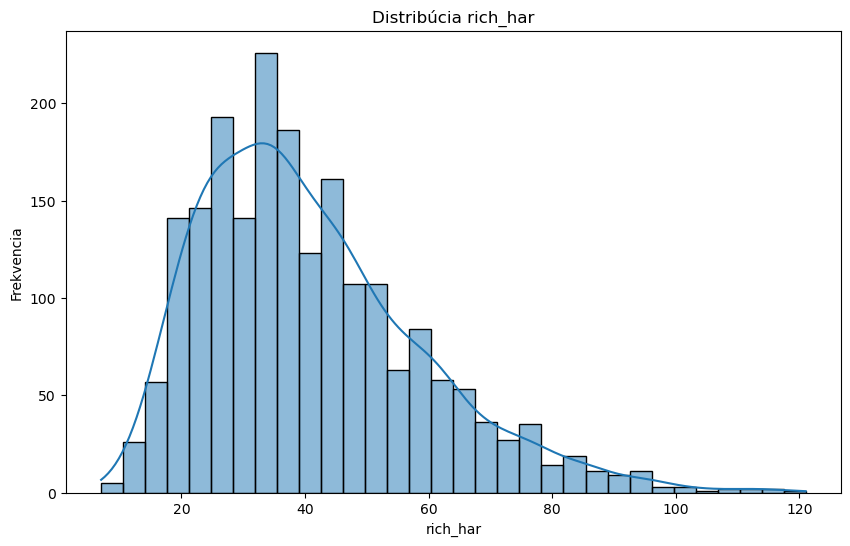

Štatistiky pre rich_har:
count    2053.000000
mean       40.825621
std        17.888865
min         7.000000
25%        27.000000
50%        37.000000
75%        50.000000
max       121.000000
Name: rich_har, dtype: float64


In [15]:
# Distribúcia cieľovej premennej
plt.figure(figsize=(10, 6))
sns.histplot(data[y], kde=True)
plt.title(f'Distribúcia {y}')
plt.xlabel(y)
plt.ylabel('Frekvencia')
plt.show()

print(f"Štatistiky pre {y}:")
print(data[y].describe())

Top 20 korelácií s rich_har (bez ID stĺpcov)
rich_har          1.000000
aspect            0.479301
clim_cmi          0.460779
clim_b12          0.446403
red_p75           0.322737
green_p75         0.319755
NBR1_p10          0.317458
blue_p75          0.316519
R1_p75            0.316210
clim_b01          0.309597
clim_gf5          0.308387
clim_gd5          0.307489
MSAVI_p25         0.303544
solar             0.298409
NDMI_p75          0.288266
NDVI_p25          0.288266
NBR1_p25          0.287328
R2_p75            0.277636
R3_p25            0.263982
SWIR_ratio_p75    0.251043
Name: rich_har, dtype: float64


Top 20 korelácií s rich_har (bez ID stĺpcov)
rich_har          1.000000
aspect            0.479301
clim_cmi          0.460779
clim_b12          0.446403
red_p75           0.322737
green_p75         0.319755
NBR1_p10          0.317458
blue_p75          0.316519
R1_p75            0.316210
clim_b01          0.309597
clim_gf5          0.308387
clim_gd5          0.307489
MSAVI_p25         0.303544
solar             0.298409
NDMI_p75          0.288266
NDVI_p25          0.288266
NBR1_p25          0.287328
R2_p75            0.277636
R3_p25            0.263982
SWIR_ratio_p75    0.251043
Name: rich_har, dtype: float64


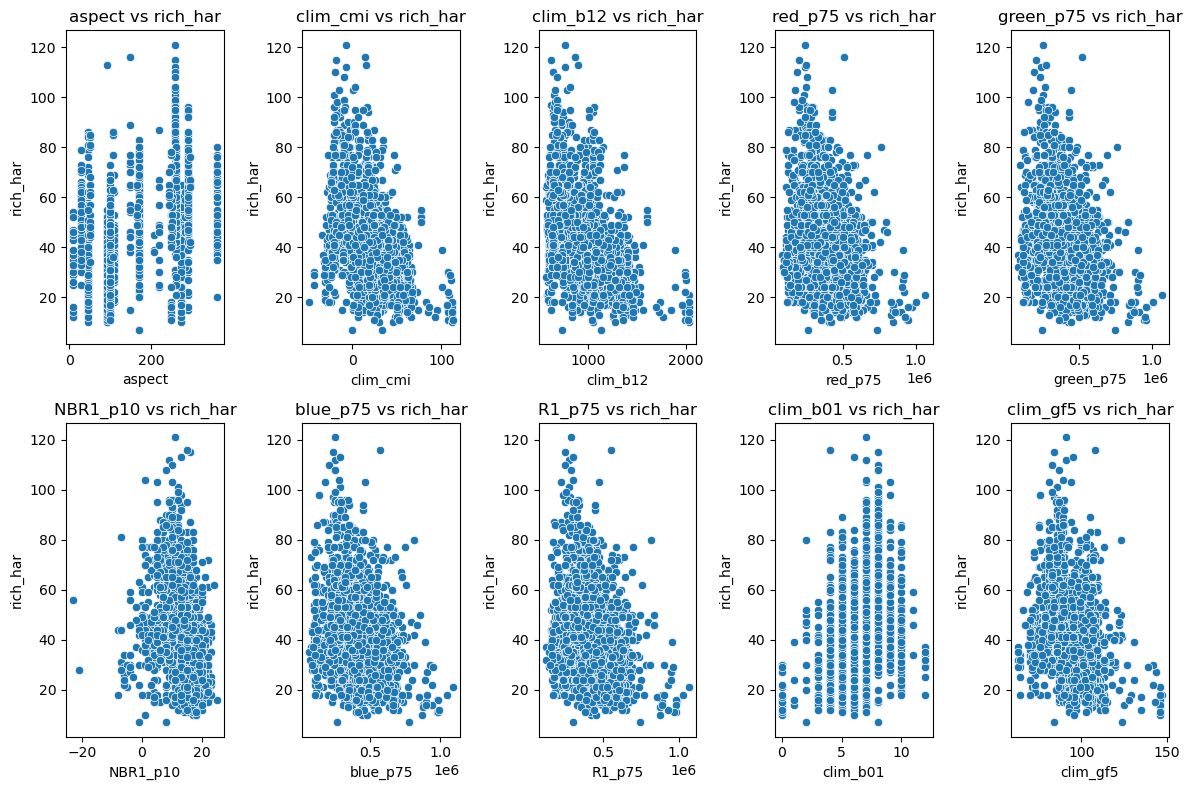

In [20]:
# Korelácie s cieľovou premennou (ignorujeme ID stĺpce)
numeric_cols = data.select_dtypes(include=[np.number]).columns
id_cols = [col for col in numeric_cols if 'id' in col.lower() or 'objectid' in col.lower()]
feature_cols = [col for col in numeric_cols if col not in id_cols + [y]]
correlations = data[feature_cols].corr()[y].abs().sort_values(ascending=False)
print("Top 20 korelácií s", y, "(bez ID stĺpcov)")
print(correlations.head(20))

# Vizualizácia top korelácií
top_corr_cols = correlations.index[1:11]  # Prvých 10 okrem seba
plt.figure(figsize=(12, 8))
for i, col in enumerate(top_corr_cols):
    plt.subplot(2, 5, i+1)
    sns.scatterplot(x=data[col], y=data[y])
    plt.title(f'{col} vs {y}')
    plt.xlabel(col)
    plt.ylabel(y)
plt.tight_layout()
plt.show()

In [18]:
# Kategorizácia premenných (predpokladané na základe názvov)
satellite_cols = [col for col in data.columns if 'sentinel' in col.lower() or 'ndvi' in col.lower() or 'band' in col.lower()]
management_cols = [col for col in data.columns if 'manag' in col.lower() or 'farm' in col.lower() or 'crop' in col.lower()]
environmental_cols = [col for col in data.columns if col not in satellite_cols + management_cols + [y, 'geometry']]

print(f"Satelitné premenné: {len(satellite_cols)}")
print(f"Manažmentové premenné: {len(management_cols)}")
print(f"Environmentálne premenné: {len(environmental_cols)}")

# Priemerné korelácie po kategóriách (len pre tie, ktoré sú v correlations)
sat_corr_cols = [col for col in satellite_cols if col in correlations.index]
man_corr_cols = [col for col in management_cols if col in correlations.index]
env_corr_cols = [col for col in environmental_cols if col in correlations.index]

sat_corr = correlations[sat_corr_cols].mean() if sat_corr_cols else 0
man_corr = correlations[man_corr_cols].mean() if man_corr_cols else 0
env_corr = correlations[env_corr_cols].mean() if env_corr_cols else 0

print(f"\nPriemerná absolútna korelácia - Satelitné: {sat_corr:.3f}")
print(f"Priemerná absolútna korelácia - Manažmentové: {man_corr:.3f}")
print(f"Priemerná absolútna korelácia - Environmentálne: {env_corr:.3f}")

Satelitné premenné: 17
Manažmentové premenné: 4
Environmentálne premenné: 195

Priemerná absolútna korelácia - Satelitné: 0.108
Priemerná absolútna korelácia - Manažmentové: 0.030
Priemerná absolútna korelácia - Environmentálne: 0.134


In [ ]:
# Definovanie skupín premenných na základe používateľovej kategorizácie
predictor_groups = {
    # Spectral bands (raw reflectance statistics)
    "spectral_bands": [
        'blue_p10','blue_p25','blue_p50','blue_p75','blue_p90','blue_median','blue_stdDev',
        'green_p10','green_p25','green_p50','green_p75','green_p90','green_median','green_stdDev',
        'red_p10','red_p25','red_p50','red_p75','red_p90','red_median','red_stdDev',
        'nir_p10','nir_p25','nir_p50','nir_p75','nir_p90','nir_median','nir_stdDev',
        'swir1_p10','swir1_p25','swir1_p50','swir1_p75','swir1_p90','swir1_median','swir1_stdDev',
        'swir2_p10','swir2_p25','swir2_p50','swir2_p75','swir2_p90','swir2_median','swir2_stdDev',
        'R1_p10','R1_p25','R1_p50','R1_p75','R1_p90','R1_median','R1_stdDev',
        'R2_p10','R2_p25','R2_p50','R2_p75','R2_p90','R2_median','R2_stdDev',
        'R3_p10','R3_p25','R3_p50','R3_p75','R3_p90','R3_median','R3_stdDev'
    ],
    # Vegetation indices
    "vegetation_indices": [
        'NDVI_p10','NDVI_p25','NDVI_p50','NDVI_p75','NDVI_p90','NDVI_median','NDVI_stdDev',
        'MSAVI_p10','MSAVI_p25','MSAVI_p50','MSAVI_p75','MSAVI_p90','MSAVI_median','MSAVI_stdDev'
    ],
    # Seasonal / temporal aggregates
    "seasonal_features": [
        'Spring_NDVI_median','Spring_NDVI_stdDev',
        'Spring_EVI_median','Spring_EVI_stdDev',
        'Spring_MSAVI_median','Spring_MSAVI_stdDev',
        'Spring_NDMI_median','Spring_NDMI_stdDev',
        'Spring_SWIR_ratio_median','Spring_SWIR_ratio_stdDev',
        'Summer_NDVI_median','Summer_NDVI_stdDev',
        'Summer_EVI_median','Summer_EVI_stdDev',
        'Summer_MSAVI_median','Summer_MSAVI_stdDev',
        'Summer_NDMI_median','Summer_NDMI_stdDev',
        'Summer_SWIR_ratio_median','Summer_SWIR_ratio_stdDev',
        'Autumn_NDVI_median','Autumn_NDVI_stdDev',
        'Autumn_EVI_median','Autumn_EVI_stdDev',
        'Autumn_MSAVI_median','Autumn_MSAVI_stdDev',
        'Autumn_NDMI_median','Autumn_NDMI_stdDev',
        'Autumn_SWIR_ratio_median','Autumn_SWIR_ratio_stdDev',
        'Spring_Summer_NDVI_median','Spring_Summer_NDVI_stdDev',
        'Spring_Summer_EVI_median','Spring_Summer_EVI_stdDev',
        'Spring_Summer_MSAVI_median','Spring_Summer_MSAVI_stdDev',
        'Spring_Summer_NDMI_median','Spring_Summer_NDMI_stdDev',
        'Spring_Summer_SWIR_ratio_median','Spring_Summer_SWIR_ratio_stdDev',
        'SummerAutumn_NDVI_median','SummerAutumn_NDVI_stdDev',
        'SummerAutumn_EVI_median','SummerAutumn_EVI_stdDev',
        'SummerAutumn_MSAVI_median','SummerAutumn_MSAVI_stdDev',
        'SummerAutumn_NDMI_median','SummerAutumn_NDMI_stdDev',
        'SummerAutumn_SWIR_ratio_median','SummerAutumn_SWIR_ratio_stdDev'
    ],
    # Land cover proximity
    "landcover_proximity": [
        'urban_prox10m','urban_prox90m','urban_prox360m','urban_prox500m',
        'forest_prox10m','forest_prox90m','forest_prox360m','forest_prox500m',
        'grassland_prox10m','grassland_prox90m','grassland_prox360m','grassland_prox500m',
        'cropland_prox10m','cropland_prox90m','cropland_prox360m','cropland_prox500m'
    ],
    # Terrain
    "terrain": [
        'elevation','slope','aspect','tpi'
    ],
    # Climate
    "climate": [
        'clim_b01','clim_b12','clim_cmi','clim_gd5','clim_gf5'
    ],
    # Temperature / soil / background
    "temperature_background": [
        'smTno_009m','smTno_045m','SmTno_090m',
        'bgTno_009m','bgTno_045m','bgTno_090m'
    ],
    # Structure / canopy
    "vegetation_structure": [
        'chm_m','chm_sd'
    ],
    # Human / anthropogenic
    "anthropogenic": [
        'nightlight','solar'
    ],
    # Mowing history
    "mowing_history": [
        'Carpathians_2018_Mowing_Intensity_DOY1',
        'Carpathians_2019_Mowing_Intensity_DOY1',
        'Carpathians_2020_Mowing_Intensity_DOY1',
        'Carpathians_2021_Mowing_Intensity_DOY1',
        'Carpathians_2022_Mowing_Intensity_DOY1',
        'Carpathians_2023_Mowing_Intensity_DOY1',
        'Carpathians_2024_Mowing_Intensity_DOY1',
        'Carpathians_2018_Mowing_Intensity_n_mowing',
        'Carpathians_2019_Mowing_Intensity_n_mowing',
        'Carpathians_2020_Mowing_Intensity_n_mowing',
        'Carpathians_2021_Mowing_Intensity_n_mowing',
        'Carpathians_2022_Mowing_Intensity_n_mowing',
        'Carpathians_2023_Mowing_Intensity_n_mowing',
        'Carpathians_2024_Mowing_Intensity_n_mowing'
    ],
    # Management / timing
    "management": [
        'DOY1',
        'n_mowing'
    ]
}

# Kombinovanie do hlavných kategórií
satellite_cols = []
for group in ["spectral_bands", "vegetation_indices", "seasonal_features", "landcover_proximity"]:
    satellite_cols.extend(predictor_groups[group])

management_cols = predictor_groups["management"] + predictor_groups["mowing_history"]

environmental_cols = []
for group in ["terrain", "climate", "temperature_background", "vegetation_structure", "anthropogenic"]:
    environmental_cols.extend(predictor_groups[group])

print(f"Satelitné premenné: {len(satellite_cols)}")
print(f"Manažmentové premenné: {len(management_cols)}")
print(f"Environmentálne premenné: {len(environmental_cols)}")

# Priemerné korelácie po kategóriách
sat_corr = correlations[[col for col in satellite_cols if col in correlations.index]].mean()
man_corr = correlations[[col for col in management_cols if col in correlations.index]].mean()
env_corr = correlations[[col for col in environmental_cols if col in correlations.index]].mean()

print(f"\nPriemerná absolútna korelácia - Satelitné: {sat_corr:.3f}")
print(f"Priemerná absolútna korelácia - Manažmentové: {man_corr:.3f}")
print(f"Priemerná absolútna korelácia - Environmentálne: {env_corr:.3f}")

Satelitné premenné: 143
Manažmentové premenné: 16
Environmentálne premenné: 19

Priemerná absolútna korelácia - Satelitné: 0.126
Priemerná absolútna korelácia - Manažmentové: 0.073
Priemerná absolútna korelácia - Environmentálne: 0.192


# Ďalšie kroky pre modelovanie Species Richness

Na základe EDA môžeme navrhnúť tieto kroky:

1. **Predspracovanie dát:**
   - Odstrániť alebo imputovať chýbajúce hodnoty
   - Štandardizovať/normalizovať numerické premenné
   - Kódovať kategorické premenné (ak nejaké sú)

2. **Výber premenných (Feature Selection):**
   - Použiť korelácie na výber top premenných
   - Skúsiť Recursive Feature Elimination (RFE)
   - Alebo Lasso regresiu pre automatický výber

3. **Modelovanie:**
   - **Lineárna regresia** ako baseline
   - **Random Forest** alebo **Gradient Boosting** pre nelineárne vzťahy
   - **Neural Networks** pre komplexné vzťahy
   - Skúsiť **Spatial models** (napr. Spatial Lag/ Error models) kvôli geografickým dátam

4. **Validácia:**
   - Cross-validation
   - Metriky: RMSE, MAE, R²
   - Kontrola overfittingu

5. **Interpretácia:**
   - Feature importance
   - Partial dependence plots
   - SHAP values

Začnite s jednoduchým modelom a postupne pridávajte komplexnosť.

Manažmentové premenné:


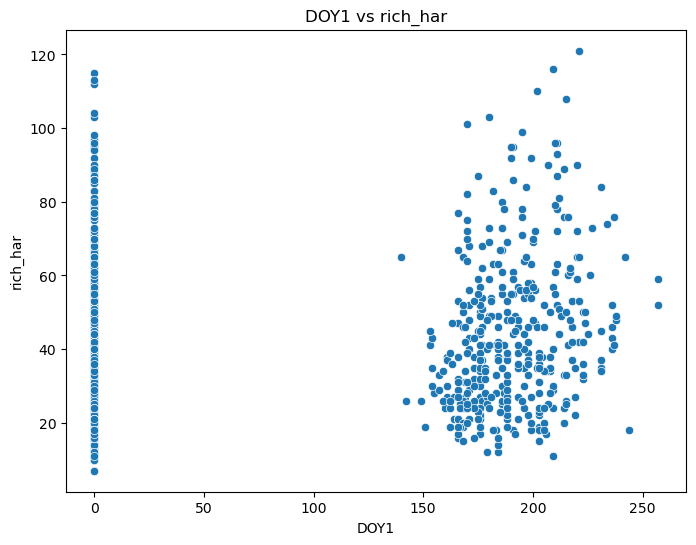

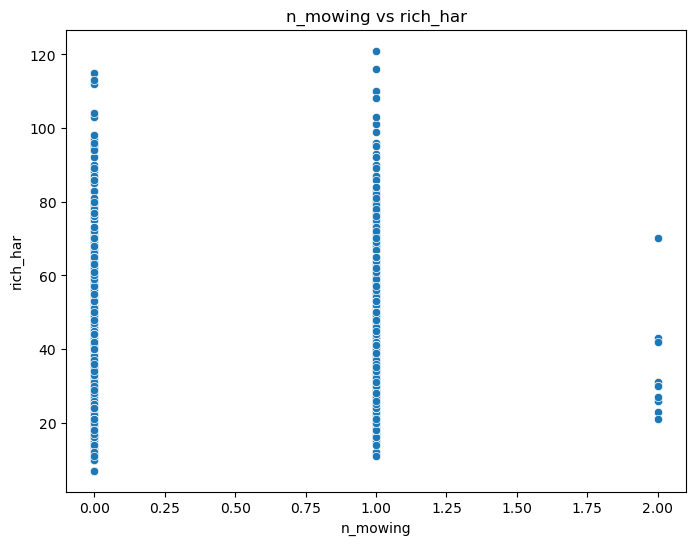

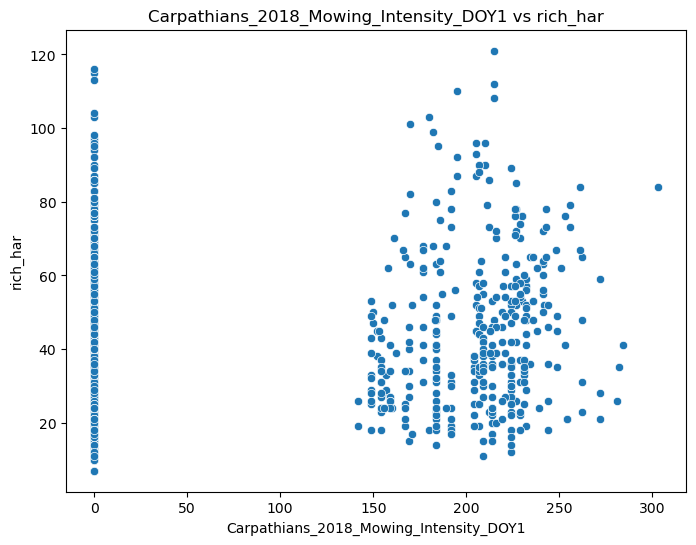

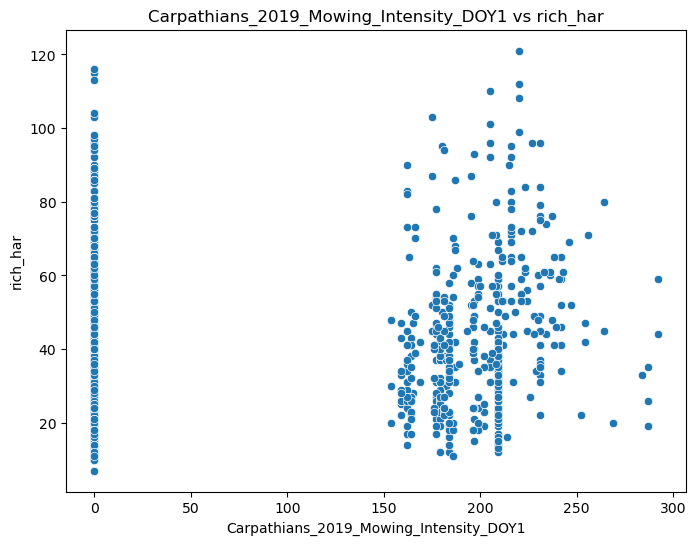

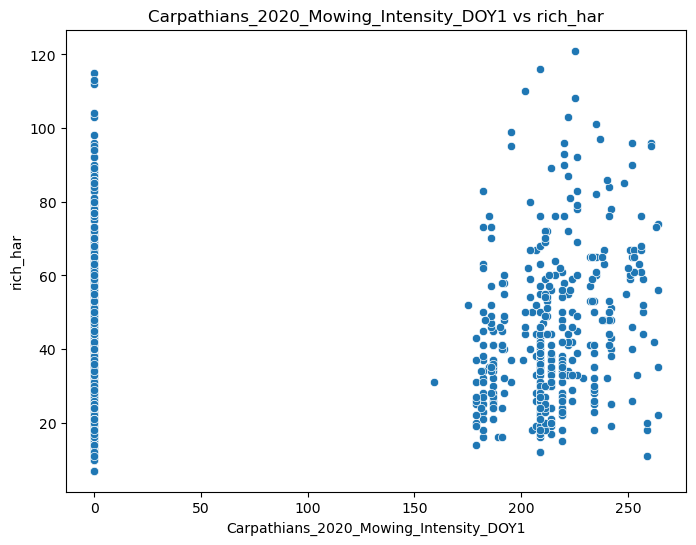

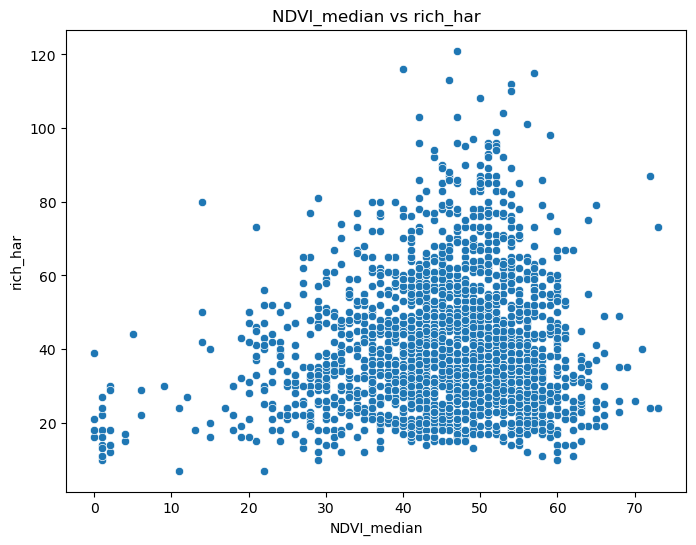

Summer NDVI premenné: ['Spring_Summer_NDVI_median', 'Spring_Summer_NDVI_stdDev', 'Summer_NDVI_median', 'Summer_NDVI_stdDev']


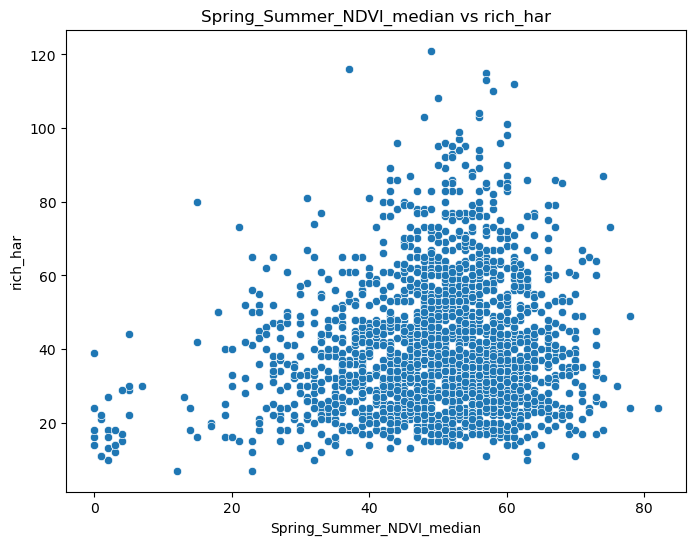

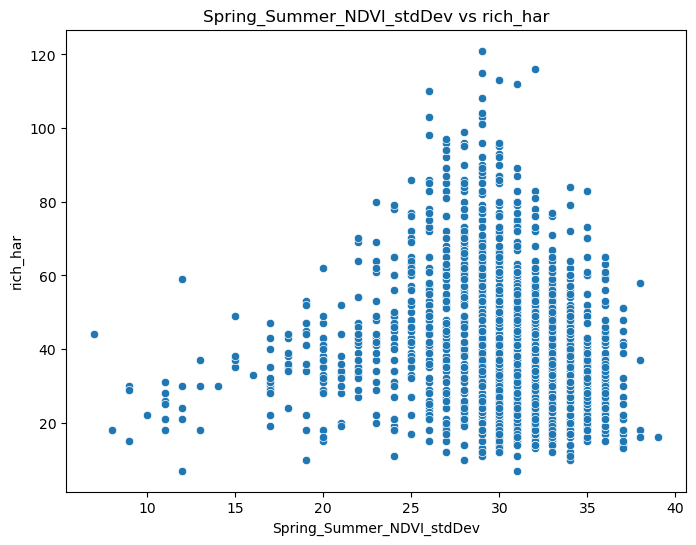

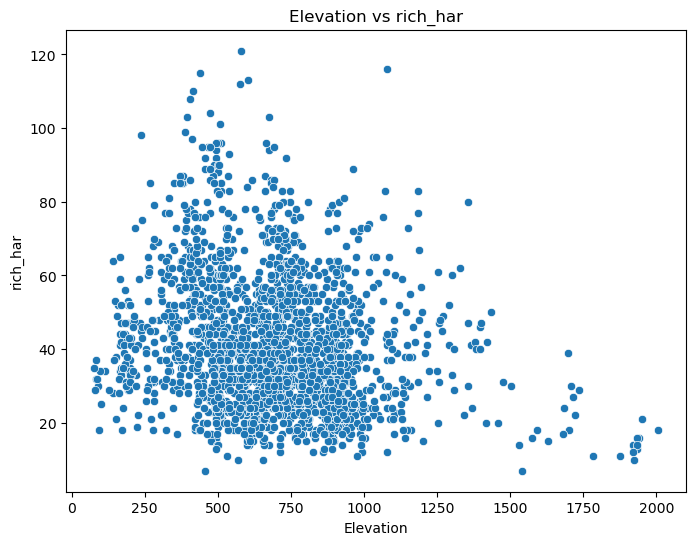

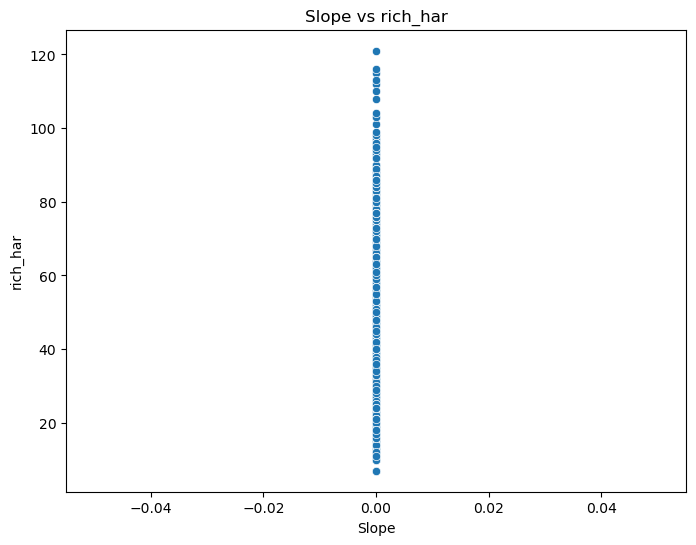

Climate premenné:


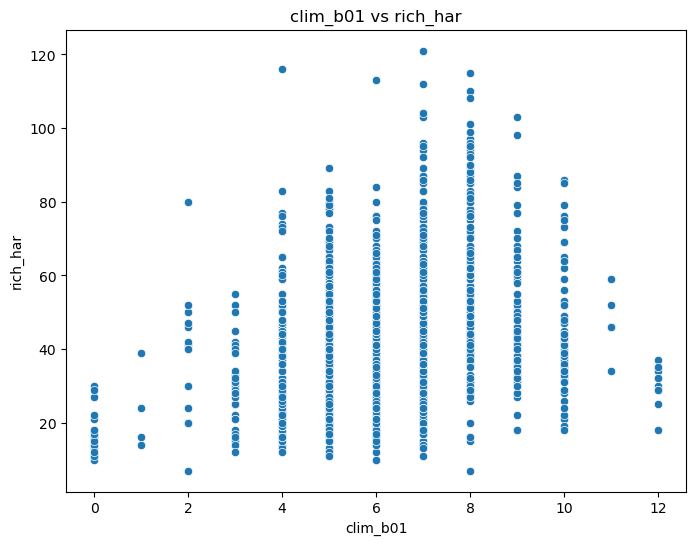

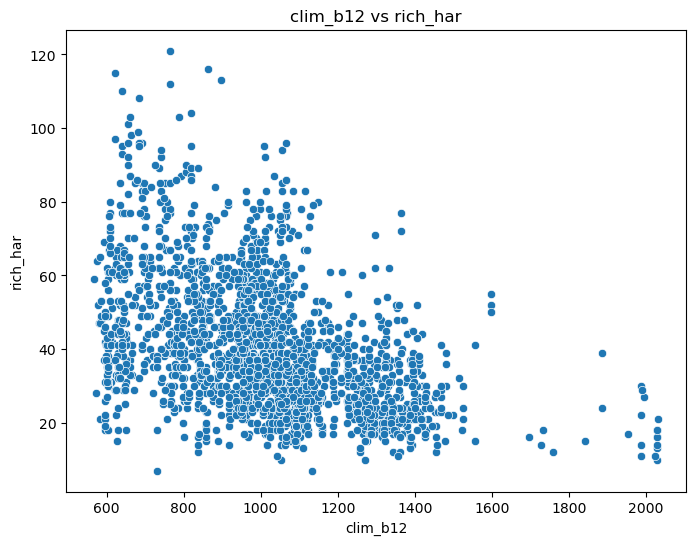

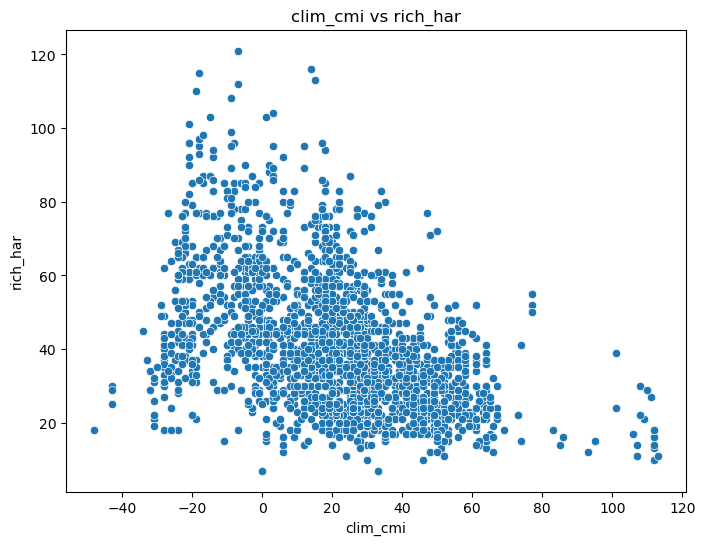

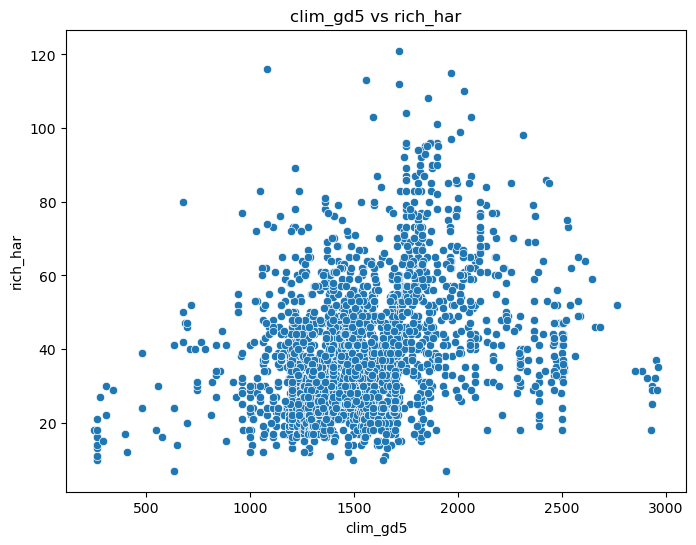

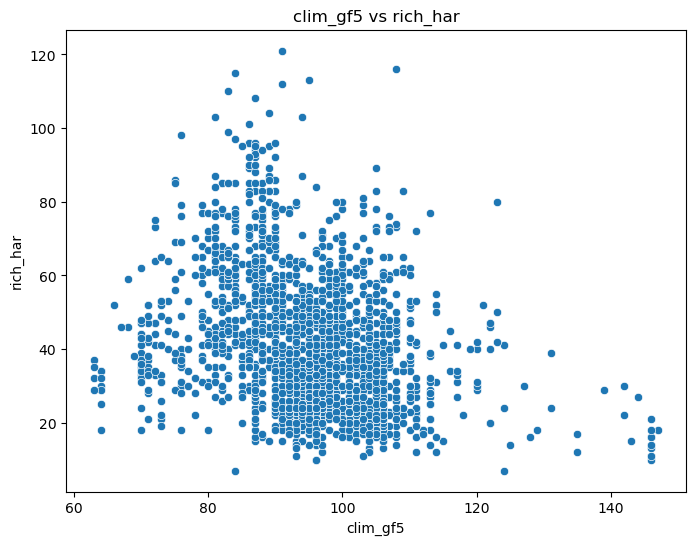

Anthropogenic premenné:


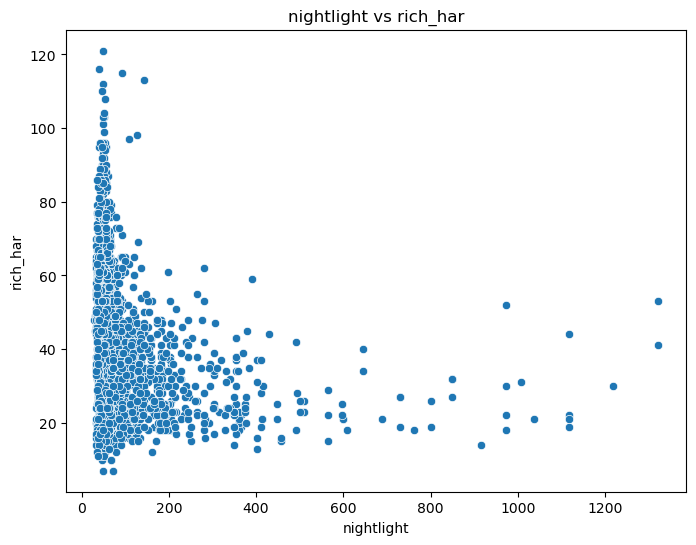

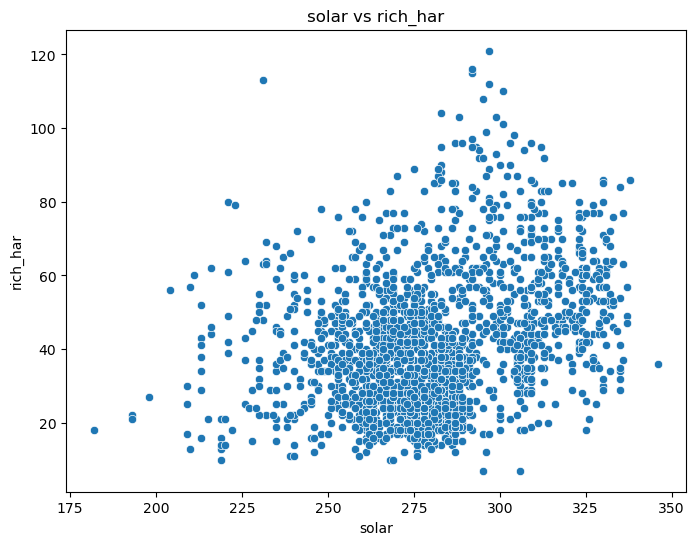

Soil/Temperature premenné:


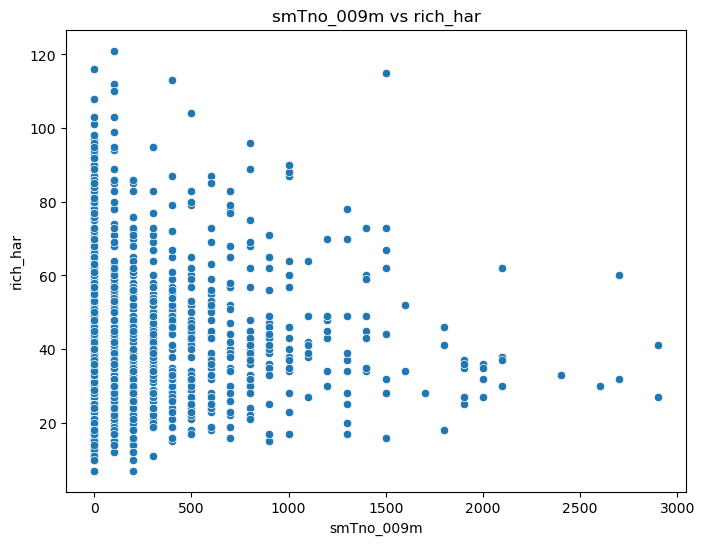

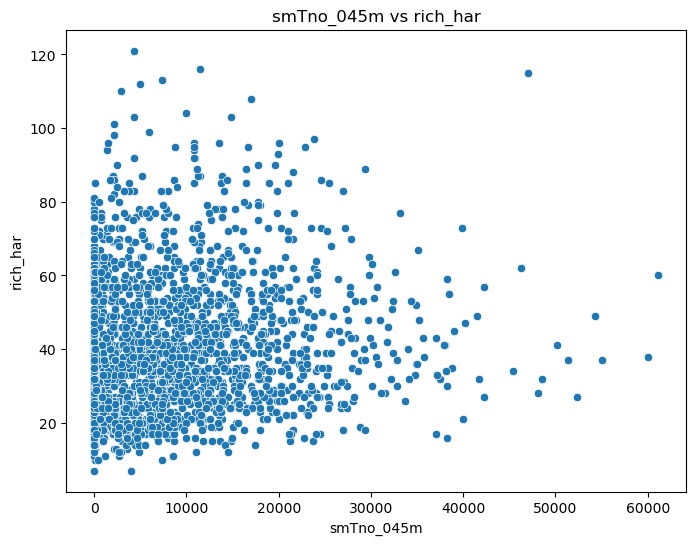

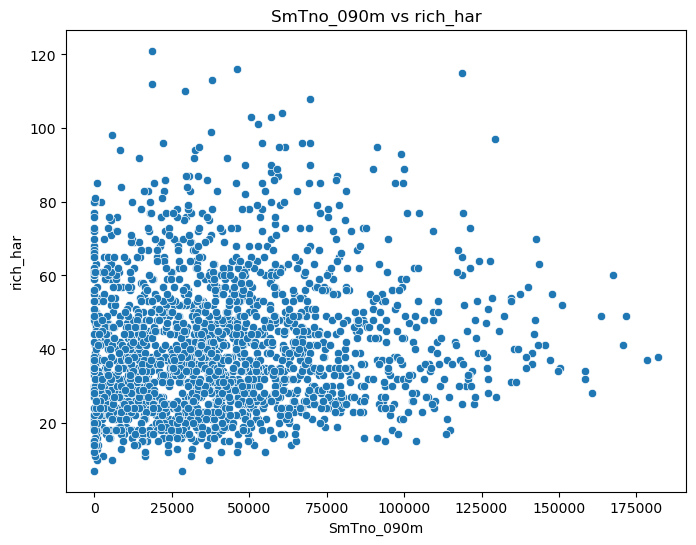

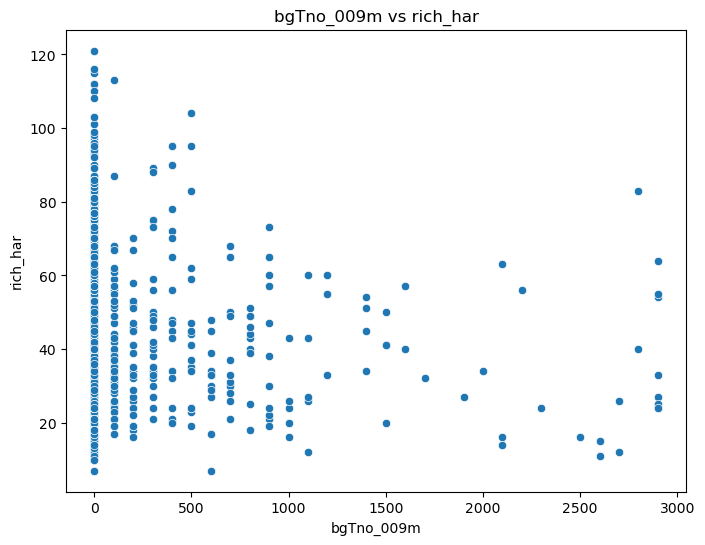

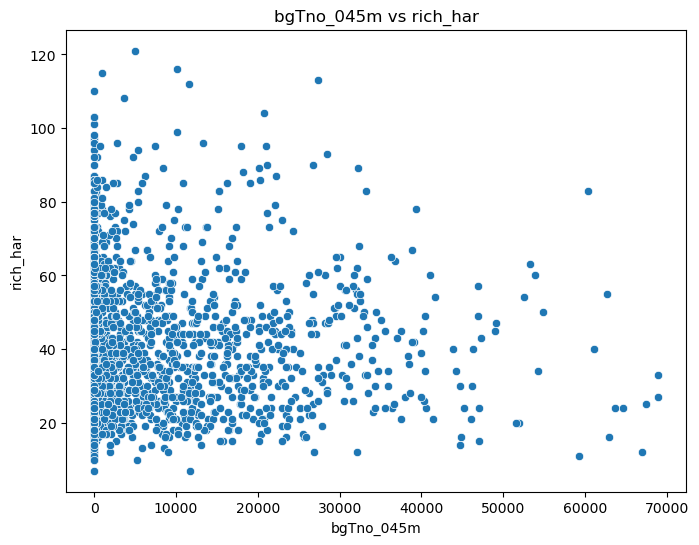

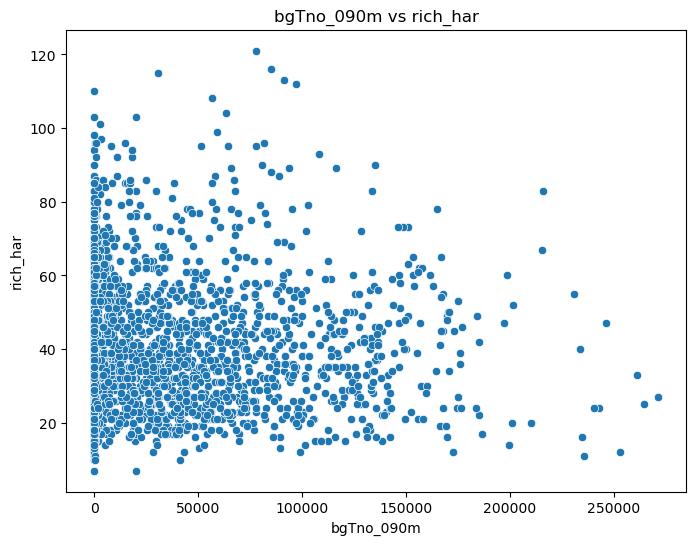

In [26]:
# Grafy pre rôzne skupiny premenných v porovnaní s rich_har

# Manažmentové premenné
print("Manažmentové premenné:")
for col in management_cols[:5]:  # Prvých 5 kvôli prehľadnosti
    if col in data.columns:
        plt.figure(figsize=(8, 6))
        sns.scatterplot(x=data[col], y=data[y])
        plt.title(f'{col} vs {y}')
        plt.xlabel(col)
        plt.ylabel(y)
        plt.show()

# NDVI median
plt.figure(figsize=(8, 6))
sns.scatterplot(x=data['NDVI_median'], y=data[y])
plt.title('NDVI_median vs rich_har')
plt.xlabel('NDVI_median')
plt.ylabel('rich_har')
plt.show()

# Summer_NDVI
summer_ndvi_cols = [col for col in data.columns if 'Summer_NDVI' in col]
print(f"Summer NDVI premenné: {summer_ndvi_cols}")
for col in summer_ndvi_cols[:2]:  # Prvých 2
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=data[col], y=data[y])
    plt.title(f'{col} vs {y}')
    plt.xlabel(col)
    plt.ylabel(y)
    plt.show()

# Elevation
plt.figure(figsize=(8, 6))
sns.scatterplot(x=data['elevation'], y=data[y])
plt.title('Elevation vs rich_har')
plt.xlabel('Elevation')
plt.ylabel('rich_har')
plt.show()

# Slope
plt.figure(figsize=(8, 6))
sns.scatterplot(x=data['slope'], y=data[y])
plt.title('Slope vs rich_har')
plt.xlabel('Slope')
plt.ylabel('rich_har')
plt.show()

# Climate premenné
print("Climate premenné:")
for col in predictor_groups["climate"]:
    if col in data.columns:
        plt.figure(figsize=(8, 6))
        sns.scatterplot(x=data[col], y=data[y])
        plt.title(f'{col} vs {y}')
        plt.xlabel(col)
        plt.ylabel(y)
        plt.show()

# Human (anthropogenic)
print("Anthropogenic premenné:")
for col in predictor_groups["anthropogenic"]:
    if col in data.columns:
        plt.figure(figsize=(8, 6))
        sns.scatterplot(x=data[col], y=data[y])
        plt.title(f'{col} vs {y}')
        plt.xlabel(col)
        plt.ylabel(y)
        plt.show()

# Soil (temperature_background)
print("Soil/Temperature premenné:")
for col in predictor_groups["temperature_background"]:
    if col in data.columns:
        plt.figure(figsize=(8, 6))
        sns.scatterplot(x=data[col], y=data[y])
        plt.title(f'{col} vs {y}')
        plt.xlabel(col)
        plt.ylabel(y)
        plt.show()

Spektrálne median premenné: ['blue_median', 'green_median', 'red_median', 'nir_median', 'swir1_median', 'swir2_median', 'R1_median', 'R2_median', 'R3_median']


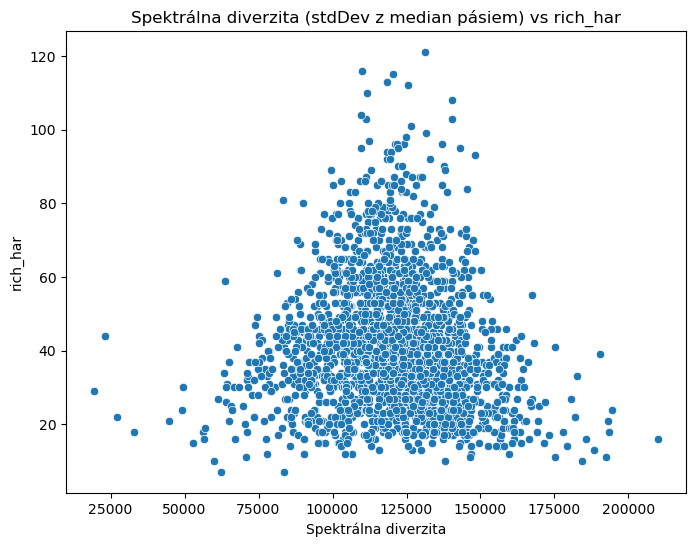

Korelácia spektrálnej diverzity s rich_har: -0.097


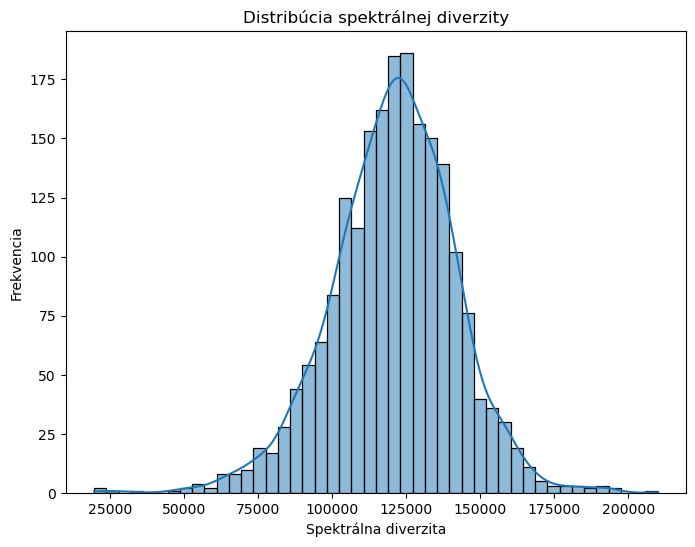

In [28]:
# Spektrálna diverzita - hypotéza o súvislosti s biodiverzitou
# Vypočítame štandardnú odchýlku z median hodnôt spektrálnych pásiem ako mieru spektrálnej diverzity

spectral_median_cols = [col for col in predictor_groups["spectral_bands"] if 'median' in col and col in data.columns]
print(f"Spektrálne median premenné: {spectral_median_cols}")

# Vypočítame spektrálnu diverzitu (štandardná odchýlka z median hodnôt)
data['spectral_diversity'] = data[spectral_median_cols].std(axis=1)

# Scatter plot spektrálnej diverzity vs rich_har
plt.figure(figsize=(8, 6))
sns.scatterplot(x=data['spectral_diversity'], y=data[y])
plt.title('Spektrálna diverzita (stdDev z median pásiem) vs rich_har')
plt.xlabel('Spektrálna diverzita')
plt.ylabel('rich_har')
plt.show()

# Korelácia
spectral_corr = data[['spectral_diversity', y]].corr().iloc[0, 1]
print(f"Korelácia spektrálnej diverzity s {y}: {spectral_corr:.3f}")

# Histogram spektrálnej diverzity
plt.figure(figsize=(8, 6))
sns.histplot(data['spectral_diversity'], kde=True)
plt.title('Distribúcia spektrálnej diverzity')
plt.xlabel('Spektrálna diverzita')
plt.ylabel('Frekvencia')
plt.show()

# Modelovanie Species Richness

Na základe EDA môžeme začať s modelovaním. Použijeme environmentálne premenné ako základ, keďže majú najvyššiu koreláciu.

In [32]:
# Jednoduchý Random Forest pre vybrané environmentálne, satelitné a manažmentové premenné
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RepeatedKFold, cross_validate

# Kandidátne premenné z EDA naprieč všetkými hlavnými skupinami
candidate_features = [
    col for col in (environmental_cols + satellite_cols + management_cols)
    if col in data.columns
]
candidate_features = list(dict.fromkeys(candidate_features))

# Očistenie dát pre modelovanie
model_data = (
    data[candidate_features + [y]]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .copy()
)

X = model_data[candidate_features]
y_model = model_data[y]

# Predbežný RF len na určenie dôležitosti a výber top premenných
rf_selector = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
)
rf_selector.fit(X, y_model)

feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_selector.feature_importances_
}).sort_values('importance', ascending=False)

selected_features = feature_importance.head(50)['feature'].tolist()
X_selected = X[selected_features]

print(f'Počet kandidátnych premenných: {len(candidate_features)}')
print('Použité premenné pre finálny RF model:')
print(selected_features)
display(feature_importance.head(20))

# Náhodné CV: opakovaný KFold so shuffle cez random_state
rf_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
)

cv = RepeatedKFold(n_splits=5, n_repeats=10, random_state=42)
scoring = {
    'r2': 'r2',
    'mae': 'neg_mean_absolute_error',
    'rmse': 'neg_root_mean_squared_error',
}

# n_jobs=1 pri CV kvôli stabilite v notebook prostredí
cv_results = cross_validate(
    rf_model,
    X_selected,
    y_model,
    cv=cv,
    scoring=scoring,
    n_jobs=1,
    return_train_score=False,
)

metrics_summary = pd.DataFrame({
    'metric': ['R2', 'MAE', 'RMSE'],
    'mean': [
        cv_results['test_r2'].mean(),
        -cv_results['test_mae'].mean(),
        -cv_results['test_rmse'].mean(),
    ],
    'std': [
        cv_results['test_r2'].std(),
        cv_results['test_mae'].std(),
        cv_results['test_rmse'].std(),
    ],
})

print(f'Počet pozorovaní po vyčistení: {len(model_data)}')
display(metrics_summary.round(4))

# Voliteľne natrénujeme model na všetkých dátach pre ďalšie použitie v notebooku
rf_model.fit(X_selected, y_model)


Počet kandidátnych premenných: 178
Použité premenné pre finálny RF model:
['aspect', 'nightlight', 'clim_b12', 'clim_cmi', 'solar', 'clim_gd5', 'Spring_NDVI_stdDev', 'grassland_prox90m', 'Spring_NDMI_stdDev', 'tpi', 'grassland_prox500m', 'elevation', 'grassland_prox360m', 'cropland_prox500m', 'SmTno_090m', 'Autumn_EVI_stdDev', 'Autumn_SWIR_ratio_median', 'smTno_045m', 'R3_p25', 'forest_prox500m', 'nir_stdDev', 'swir1_p90', 'nir_p25', 'Spring_Summer_SWIR_ratio_median', 'Carpathians_2020_Mowing_Intensity_DOY1', 'Spring_Summer_EVI_stdDev', 'blue_p10', 'Spring_EVI_median', 'bgTno_090m', 'Spring_EVI_stdDev', 'Autumn_EVI_median', 'Carpathians_2019_Mowing_Intensity_DOY1', 'Summer_EVI_stdDev', 'Summer_EVI_median', 'swir1_p10', 'blue_p75', 'Spring_Summer_EVI_median', 'swir2_p90', 'clim_gf5', 'Carpathians_2024_Mowing_Intensity_DOY1', 'Summer_SWIR_ratio_median', 'Autumn_MSAVI_stdDev', 'SummerAutumn_EVI_stdDev', 'swir2_p75', 'nir_median', 'Summer_SWIR_ratio_stdDev', 'forest_prox360m', 'swir1_p75',

,feature,importance
2,aspect,0.295656
17,nightlight,0.063585
5,clim_b12,0.054156
6,clim_cmi,0.036666
18,solar,0.025085
7,clim_gd5,0.018803
97,Spring_NDVI_stdDev,0.011004
155,grassland_prox90m,0.010886
103,Spring_NDMI_stdDev,0.010022
3,tpi,0.008141


Počet pozorovaní po vyčistení: 2053


,metric,mean,std
0,R2,0.5957,0.0338
1,MAE,8.4276,0.3907
2,RMSE,11.3323,0.6207


,n_estimators,300
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False
